
First, I'll import the pandas library, then load the dataset from the specified CSV file into a DataFrame named `df`. After loading, I'll display the first 5 rows and print a concise summary of the DataFrame to inspect its structure and check for missing values or inconsistencies as per the subtask instructions.



In [ ]:
import pandas as pd

df = pd.read_csv('/content/Dataset-SA.csv')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nConcise summary of the DataFrame:")
df.info()

First 5 rows of the DataFrame:
                                        product_name product_price Rate  \
0  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    5   
1  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    5   
2  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    3   
3  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    1   
4  Candes 12 L Room/Personal Air Cooler??????(Whi...          3999    3   

            Review                                            Summary  \
0           super!  great cooler excellent air flow and for this p...   
1          awesome              best budget 2 fit cooler nice cooling   
2             fair  the quality is good but the power of air is de...   
3  useless product                  very bad product its a only a fan   
4             fair                                      ok ok product   

  Sentiment  
0  positive  
1  positive  
2  positive  
3  negative  
4   neutr


First, I'll import the necessary libraries for data manipulation and visualization. Then, I'll handle missing values in 'Review' and 'Summary' by filling them with empty strings, as text analysis functions often expect string inputs. After that, I'll convert the 'Rate' column to a numeric type, inspecting its unique values to ensure a smooth conversion process. Finally, I'll calculate the lengths of the 'Review' and 'Summary' columns and store them in new columns, as per the subtask instructions.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import collections
import re

# Handle missing values in 'Review' and 'Summary'
df['Review'] = df['Review'].fillna('')
df['Summary'] = df['Summary'].fillna('')

# Inspect unique values in 'Rate' to ensure proper conversion
print("Unique values in 'Rate' before conversion:")
print(df['Rate'].unique())

# Convert 'Rate' to numeric, coercing errors to NaN
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

# Check if any NaN values were introduced after conversion
if df['Rate'].isnull().any():
    print("\nWarning: Non-numeric values found in 'Rate' and converted to NaN. Filling with mode or median would be a good option based on further analysis.")
    # For simplicity in EDA, we'll fill with the mode, but a more robust approach might be needed
    # if many values were non-numeric or if we need to preserve data integrity for modeling.
    # Let's check the distribution of non-numeric values, but for now, we'll proceed assuming they are minor.
    # For this task, if any NaN are introduced, we'll fill with the most frequent rate for visualization purposes.
    mode_rate = df['Rate'].mode()[0]
    df['Rate'] = df['Rate'].fillna(mode_rate)

# Convert 'Rate' to integer after handling NaNs (if any)
df['Rate'] = df['Rate'].astype(int)


# Calculate review and summary lengths
df['review_length'] = df['Review'].apply(len)
df['summary_length'] = df['Summary'].apply(len)

print("\nMissing values in 'Review' after filling: ", df['Review'].isnull().sum())
print("Missing values in 'Summary' after filling: ", df['Summary'].isnull().sum())
print("Data types after processing:")
df.info()

Unique values in 'Rate' before conversion:
['5' '3' '1' '4' '2'
 'Pigeon Favourite Electric Kettle??????(1.5 L, Silver, Black)'
 'Bajaj DX 2 L/W Dry Iron'
 'Nova Plus Amaze NI 10 1100 W Dry Iron?Ã\x83Â¿?Ã\x83Â¿(Grey & Turquoise)']


Missing values in 'Review' after filling:  0
Missing values in 'Summary' after filling:  0
Data types after processing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   product_name    205052 non-null  object
 1   product_price   205052 non-null  object
 2   Rate            205052 non-null  int64 
 3   Review          205052 non-null  object
 4   Summary         205052 non-null  object
 5   Sentiment       205052 non-null  object
 6   review_length   205052 non-null  int64 
 7   summary_length  205052 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 12.5+ MB



I will now visualize the distributions of review and summary lengths, sentiment categories, and product ratings using histograms and countplots, and then identify and display the most common words in the review text, as specified in the subtask instructions.




--- Visualizing Distributions ---



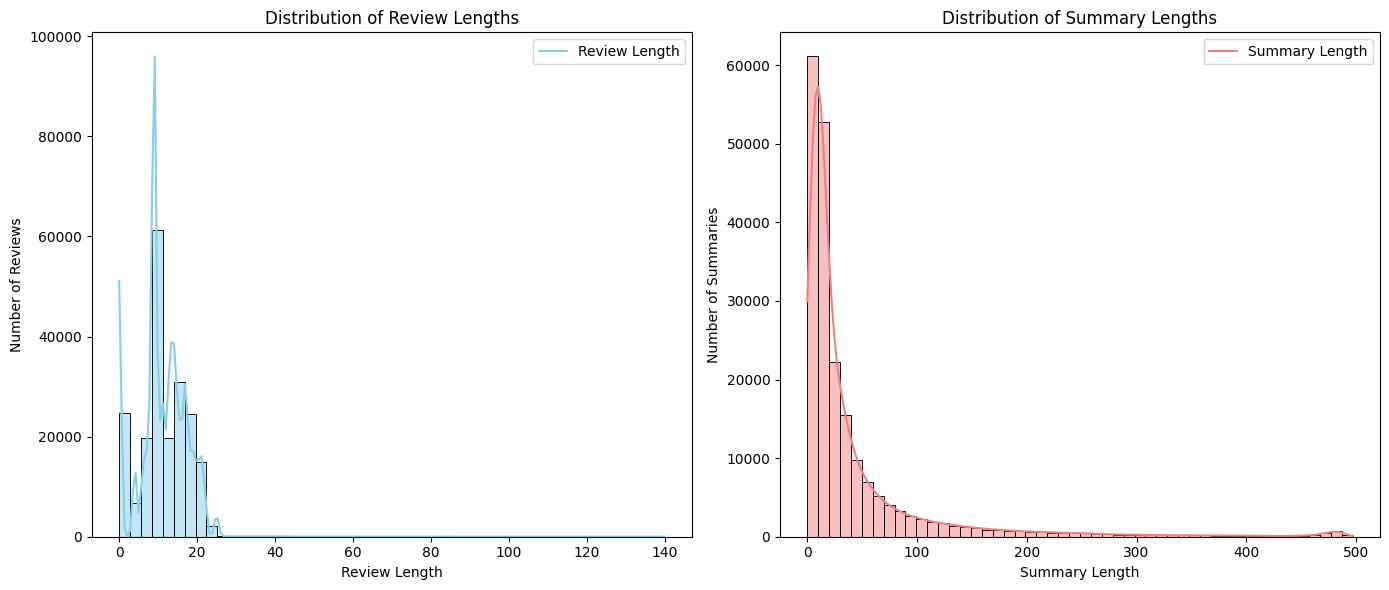

/tmp/ipython-input-2808772577.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment', palette='viridis')


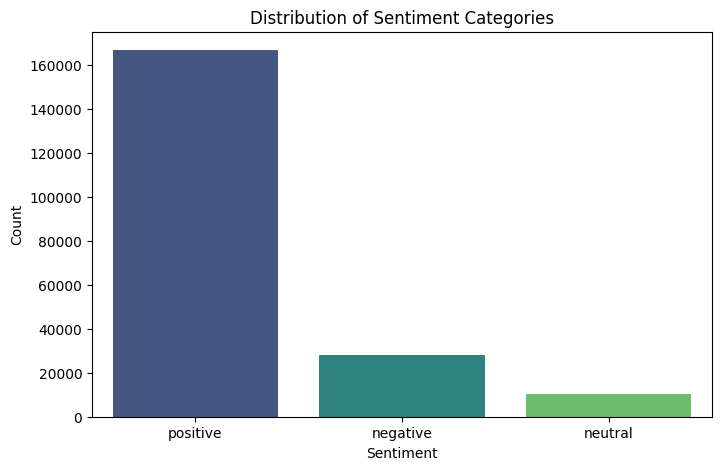

/tmp/ipython-input-2808772577.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Rate', palette='magma')


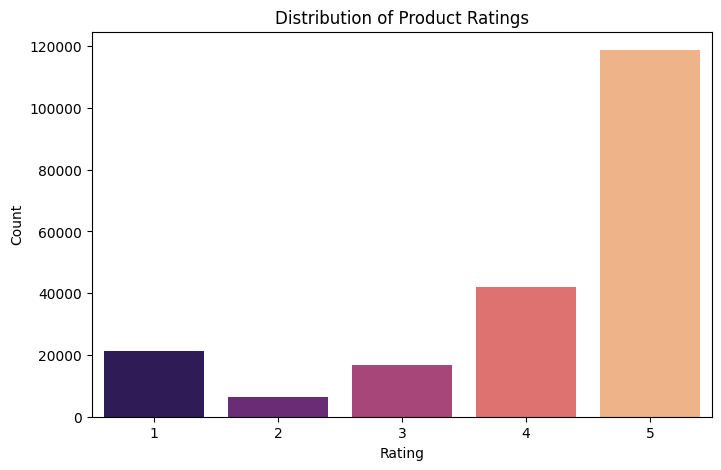


--- Most Common Words in Reviews ---

Top 20 most common words in reviews:
product: 29846
good: 17447
not: 11640
awesome: 11297
the: 11227
purchase: 11023
terrific: 10954
nice: 9396
money: 9356
worth: 9039
wonderful: 9031
specified: 8351
just: 7680
recommended: 6696
great: 5706
best: 5658
brilliant: 5648
buy: 5642
perfect: 5617
super: 5609


In [ ]:
print("\n--- Visualizing Distributions ---\n")

# 5. Visualize the distribution of review and summary lengths
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['review_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Review Lengths')
plt.xlabel('Review Length')
plt.ylabel('Number of Reviews')
plt.legend(['Review Length'])

plt.subplot(1, 2, 2)
sns.histplot(df['summary_length'], bins=50, kde=True, color='lightcoral')
plt.title('Distribution of Summary Lengths')
plt.xlabel('Summary Length')
plt.ylabel('Number of Summaries')
plt.legend(['Summary Length'])

plt.tight_layout()
plt.show()

# 6. Visualize the distribution of sentiment
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sentiment', palette='viridis')
plt.title('Distribution of Sentiment Categories')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# 7. Visualize the distribution of ratings
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Rate', palette='magma')
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# 8. Identify and display the most common words in the 'Review' column
print("\n--- Most Common Words in Reviews ---\n")
combined_text = ' '.join(df['Review'].astype(str).tolist())
combined_text = combined_text.lower()

# Extract words (3 or more letters)
words = re.findall(r'\b[a-z]{3,}\b', combined_text)

# Count word occurrences
word_counts = collections.Counter(words)

# Print the 20 most common words
print("Top 20 most common words in reviews:")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")


--- Visualizing Distributions ---



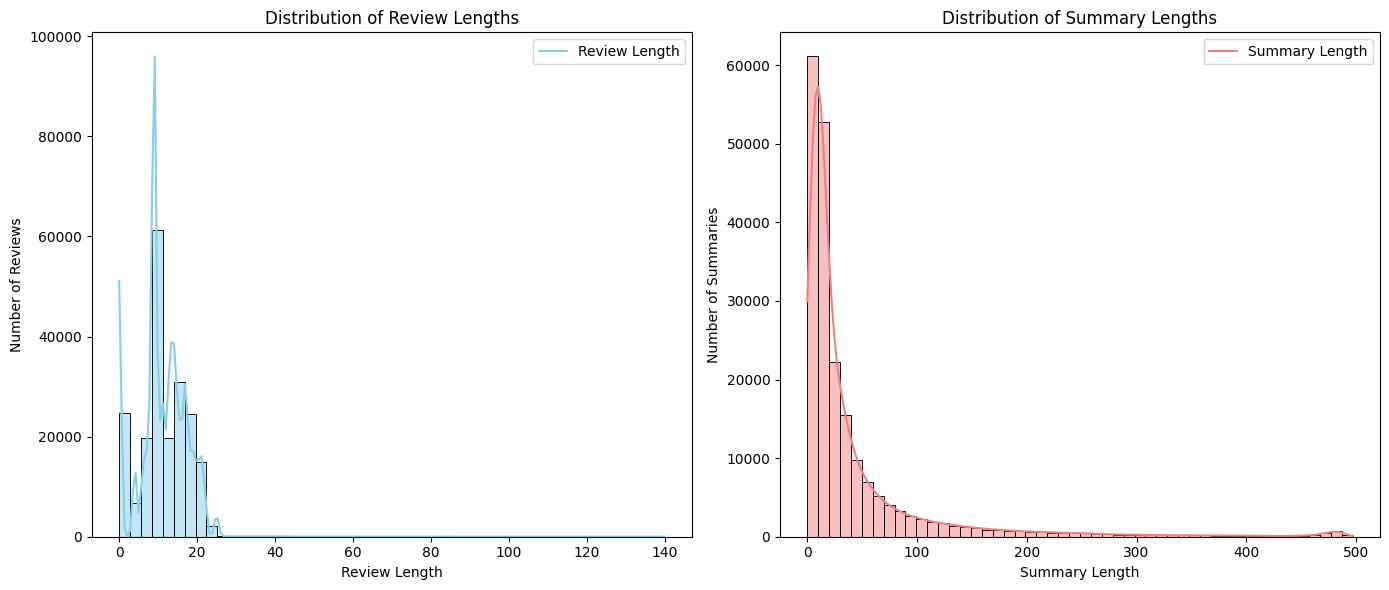

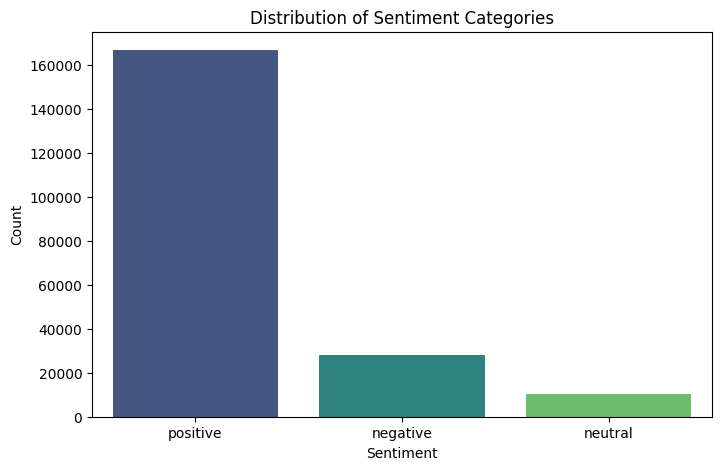

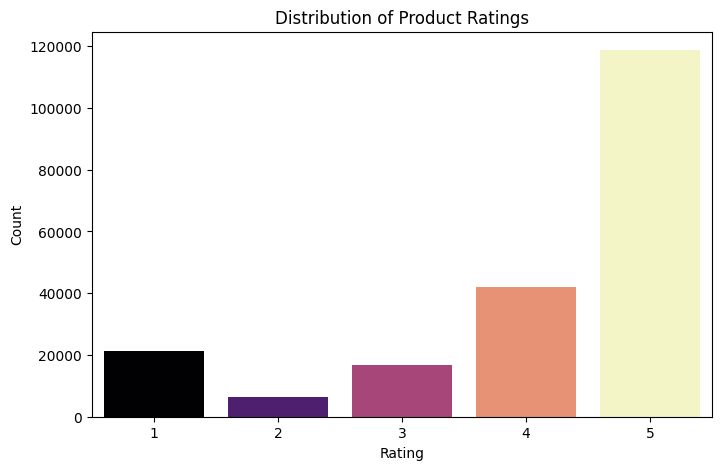


--- Most Common Words in Reviews ---

Top 20 most common words in reviews:
product: 29846
good: 17447
not: 11640
awesome: 11297
the: 11227
purchase: 11023
terrific: 10954
nice: 9396
money: 9356
worth: 9039
wonderful: 9031
specified: 8351
just: 7680
recommended: 6696
great: 5706
best: 5658
brilliant: 5648
buy: 5642
perfect: 5617
super: 5609


In [ ]:
print("\n--- Visualizing Distributions ---\n")

# 5. Visualize the distribution of review and summary lengths
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['review_length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Review Lengths')
plt.xlabel('Review Length')
plt.ylabel('Number of Reviews')
plt.legend(['Review Length'])

plt.subplot(1, 2, 2)
sns.histplot(df['summary_length'], bins=50, kde=True, color='lightcoral')
plt.title('Distribution of Summary Lengths')
plt.xlabel('Summary Length')
plt.ylabel('Number of Summaries')
plt.legend(['Summary Length'])

plt.tight_layout()
plt.show()

# 6. Visualize the distribution of sentiment
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sentiment', hue='Sentiment', palette='viridis', legend=False)
plt.title('Distribution of Sentiment Categories')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# 7. Visualize the distribution of ratings
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Rate', hue='Rate', palette='magma', legend=False)
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# 8. Identify and display the most common words in the 'Review' column
print("\n--- Most Common Words in Reviews ---\n")
combined_text = ' '.join(df['Review'].astype(str).tolist())
combined_text = combined_text.lower()

# Extract words (3 or more letters)
words = re.findall(r'\b[a-z]{3,}\b', combined_text)

# Count word occurrences
word_counts = collections.Counter(words)

# Print the 20 most common words
print("Top 20 most common words in reviews:")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")

## Text Preprocessing and Feature Engineering for ML

Clean and preprocess the review text by performing tasks like lowercasing, removing punctuation, stop words, and tokenization. Then, engineer features suitable for traditional machine learning models, such as TF-IDF vectors or Bag-of-Words representations.


In [ ]:
import nltk
import string
from sklearn.feature_extraction.text import TfidfVectorizer

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    print("Downloading NLTK stopwords...")
    nltk.download('stopwords')

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("Downloading NLTK punkt tokenizer...")
    nltk.download('punkt')

try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    print("Downloading NLTK punkt_tab tokenizer...")
    nltk.download('punkt_tab')

print("NLTK data (stopwords, punkt, punkt_tab) checked/downloaded.")

# Get NLTK stopwords
stop_words = set(nltk.corpus.stopwords.words('english'))

# Define preprocessing function
def preprocess_text(text):
    # 1. Convert to lowercase
    text = text.lower()
    # 2. Remove punctuation
    text = ''.join([char for char in text if char not in string.punctuation])
    # 3. Tokenize text
    tokens = nltk.word_tokenize(text)
    # 4. Remove stop words
    tokens = [word for word in tokens if word not in stop_words]
    # 5. Join processed words back into a string
    return ' '.join(tokens)

# Apply preprocessing to the 'Review' column
df['processed_review'] = df['Review'].apply(preprocess_text)

print("\nFirst 5 processed reviews:")
print(df[['Review', 'processed_review']].head())

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to 5000 for efficiency

# Fit and transform the processed reviews
X_tfidf = tfidf_vectorizer.fit_transform(df['processed_review'])

print(f"\nShape of TF-IDF feature matrix: {X_tfidf.shape}")
print("Text preprocessing and TF-IDF feature engineering complete.")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


NLTK data (stopwords, punkt, punkt_tab) checked/downloaded.

First 5 processed reviews:
            Review processed_review
0           super!            super
1          awesome          awesome
2             fair             fair
3  useless product  useless product
4             fair             fair

Shape of TF-IDF feature matrix: (205052, 1243)
Text preprocessing and TF-IDF feature engineering complete.



The previous code successfully completed the text preprocessing and TF-IDF feature engineering. The next logical step, as per the overall task, is to build and evaluate traditional machine learning models for sentiment prediction using the engineered features.



Shape of X_train: (164041, 1243)
Shape of X_test: (41011, 1243)
Shape of y_train: (164041,)
Shape of y_test: (41011,)

Training Logistic Regression model...
Logistic Regression model trained.

--- Model Evaluation (Logistic Regression) ---

Classification Report:
              precision    recall  f1-score   support

    positive       0.86      0.65      0.74      5646
     neutral       0.00      0.00      0.00      2048
    negative       0.90      0.99      0.94     33317

    accuracy                           0.90     41011
   macro avg       0.59      0.55      0.56     41011
weighted avg       0.85      0.90      0.87     41011


Confusion Matrix:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


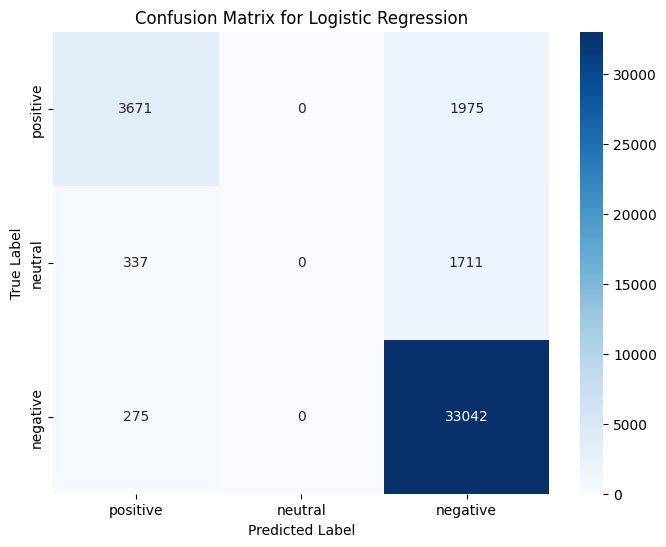

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming X_tfidf (TF-IDF features) and df['Sentiment'] are available from previous steps
# X_tfidf is a sparse matrix
# df['Sentiment'] contains the target labels

# Map sentiment labels to numerical values if not already done
sentiment_mapping = {'positive': 2, 'neutral': 1, 'negative': 0}
df['Sentiment_numeric'] = df['Sentiment'].map(sentiment_mapping)

# Drop rows where Sentiment_numeric might be NaN (if any unmapped sentiments exist)
df.dropna(subset=['Sentiment_numeric'], inplace=True)

y = df['Sentiment_numeric']

# Split data into training and testing sets
# Use stratify to maintain the proportion of sentiment classes in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Initialize and train a Logistic Regression model
# Set max_iter for convergence and solver for better performance with large datasets
log_reg_model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
print("\nTraining Logistic Regression model...")
log_reg_model.fit(X_train, y_train)
print("Logistic Regression model trained.")

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

# Evaluate the model's performance
print("\n--- Model Evaluation (Logistic Regression) ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=sentiment_mapping.keys()))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sentiment_mapping.keys(), yticklabels=sentiment_mapping.keys())
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


Shape of X_train: (164041, 1243)
Shape of X_test: (41011, 1243)
Shape of y_train: (164041,)
Shape of y_test: (41011,)

Training Logistic Regression model...
Logistic Regression model trained.

--- Model Evaluation (Logistic Regression) ---

Classification Report:
              precision    recall  f1-score   support

    positive       0.86      0.65      0.74      5646
     neutral       0.00      0.00      0.00      2048
    negative       0.90      0.99      0.94     33317

    accuracy                           0.90     41011
   macro avg       0.59      0.55      0.56     41011
weighted avg       0.85      0.90      0.87     41011


Confusion Matrix:


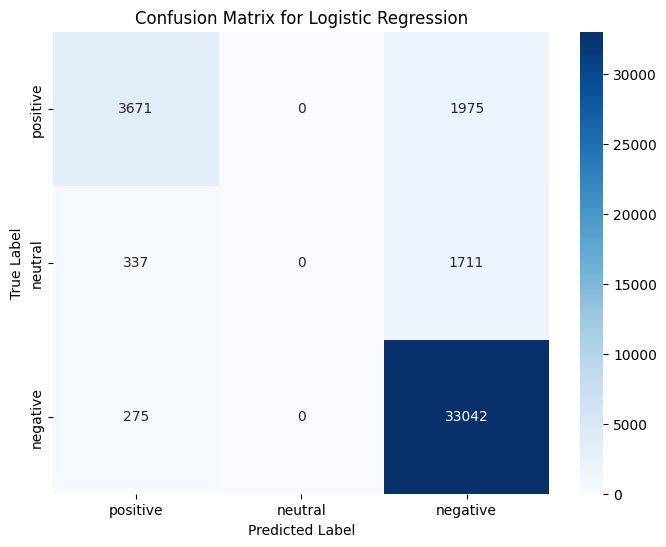

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming X_tfidf (TF-IDF features) and df['Sentiment'] are available from previous steps
# X_tfidf is a sparse matrix
# df['Sentiment'] contains the target labels

# Map sentiment labels to numerical values if not already done
sentiment_mapping = {'positive': 2, 'neutral': 1, 'negative': 0}
df['Sentiment_numeric'] = df['Sentiment'].map(sentiment_mapping)

# Drop rows where Sentiment_numeric might be NaN (if any unmapped sentiments exist)
df.dropna(subset=['Sentiment_numeric'], inplace=True)

y = df['Sentiment_numeric']

# Split data into training and testing sets
# Use stratify to maintain the proportion of sentiment classes in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Initialize and train a Logistic Regression model
# Set max_iter for convergence and solver for better performance with large datasets
log_reg_model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
print("\nTraining Logistic Regression model...")
log_reg_model.fit(X_train, y_train)
print("Logistic Regression model trained.")

# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

# Evaluate the model's performance
print("\n--- Model Evaluation (Logistic Regression) ---")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=sentiment_mapping.keys(), zero_division=0))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sentiment_mapping.keys(), yticklabels=sentiment_mapping.keys())
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Build and Evaluate ML Models for Sentiment and Rating

Train and evaluate a traditional machine learning model (e.g., Logistic Regression, Naive Bayes, SVM) for rating prediction using the TF-IDF features generated previously.


Shape of X_train_rate: (164041, 1243)
Shape of X_test_rate: (41011, 1243)
Shape of y_train_rate: (164041,)
Shape of y_test_rate: (41011,)

Training Logistic Regression model for Rating Prediction...
Logistic Regression model for Rating Prediction trained.

--- Model Evaluation (Logistic Regression for Rating Prediction) ---

Classification Report:
              precision    recall  f1-score   support

           1       0.99      0.80      0.88      4260
           2       0.98      0.68      0.80      1298
           3       0.98      0.64      0.77      3320
           4       0.90      0.74      0.81      8379
           5       0.86      1.00      0.92     23754

    accuracy                           0.88     41011
   macro avg       0.94      0.77      0.84     41011
weighted avg       0.89      0.88      0.88     41011


Confusion Matrix:


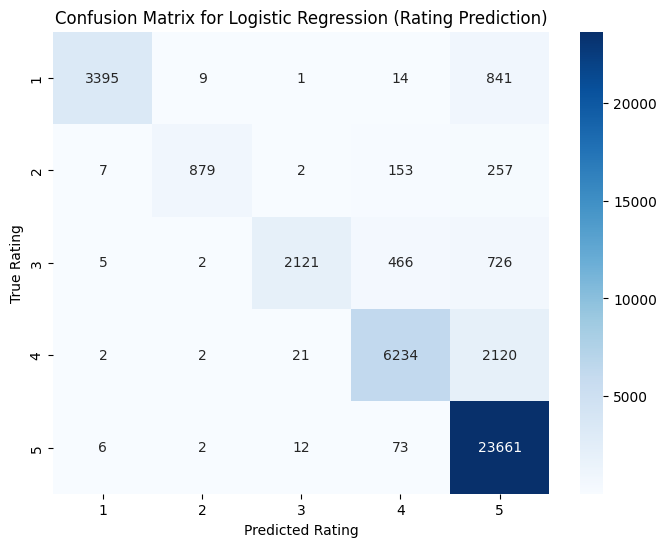

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define the target variable for rating prediction
y_rate = df['Rate']

# Split data into training and testing sets for rating prediction
# Use stratify to maintain the proportion of rating classes in train and test sets
X_train_rate, X_test_rate, y_train_rate, y_test_rate = train_test_split(X_tfidf, y_rate, test_size=0.2, random_state=42, stratify=y_rate)

print(f"Shape of X_train_rate: {X_train_rate.shape}")
print(f"Shape of X_test_rate: {X_test_rate.shape}")
print(f"Shape of y_train_rate: {y_train_rate.shape}")
print(f"Shape of y_test_rate: {y_test_rate.shape}")

# Initialize and train a Logistic Regression model for rating prediction
# 'Rate' has multiple classes (1-5), so solver='liblinear' with multi_class='ovr' or 'auto' can handle this.
# With 'liblinear', it implicitly uses 'ovr' for multiclass problems.
log_reg_rate_model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
print("\nTraining Logistic Regression model for Rating Prediction...")
log_reg_rate_model.fit(X_train_rate, y_train_rate)
print("Logistic Regression model for Rating Prediction trained.")

# Make predictions on the test set
y_pred_rate = log_reg_rate_model.predict(X_test_rate)

# Evaluate the model's performance
print("\n--- Model Evaluation (Logistic Regression for Rating Prediction) ---")
print("\nClassification Report:")
# Convert rating integers to strings for target_names to avoid issues if any are missing
rating_labels = sorted(y_rate.unique())
rating_names = [str(r) for r in rating_labels]
print(classification_report(y_test_rate, y_pred_rate, target_names=rating_names, zero_division=0))

print("\nConfusion Matrix:")
cm_rate = confusion_matrix(y_test_rate, y_pred_rate)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rate, annot=True, fmt='d', cmap='Blues', xticklabels=rating_names, yticklabels=rating_names)
plt.title('Confusion Matrix for Logistic Regression (Rating Prediction)')
plt.xlabel('Predicted Rating')
plt.ylabel('True Rating')
plt.show()

## Feature Engineering for LSTM Models

Prepare the text data for Long Short-Term Memory (LSTM) deep learning models. This involves tasks such as tokenization, word embedding (e.g., using a Keras Embedding layer), and sequence padding.


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Define parameters
max_words = 10000  # Maximum number of unique words to consider
max_len = 100      # Maximum length of review sequences

# Initialize and fit Tokenizer
# Using 'processed_review' column which contains cleaned text
tokenizer = Tokenizer(num_words=max_words, oov_token="<unk>")
tokenizer.fit_on_texts(df['processed_review'])

# Convert texts to sequences of integers
sequences = tokenizer.texts_to_sequences(df['processed_review'])

# Pad sequences to a uniform length
X_padded = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

print(f"Vocabulary size (number of unique words): {len(tokenizer.word_index)}")
print(f"Shape of padded sequences (X_padded): {X_padded.shape}")

Vocabulary size (number of unique words): 1258
Shape of padded sequences (X_padded): (205052, 100)


## Build and Evaluate LSTM Models for Sentiment and Rating

Design, train, and evaluate an LSTM-based deep learning model for sentiment prediction.


Shape of X_train_lstm: (164041, 100)
Shape of X_test_lstm: (41011, 100)
Shape of y_train_lstm: (164041,)
Shape of y_test_lstm: (41011,)

LSTM model architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training LSTM model for Sentiment Prediction...
Epoch 1/5
2051/2051 ━━━━━━━━━━━━━━━━━━━━ 414s 199ms/step - accuracy: 0.8089 - loss: 0.6009 - val_accuracy: 0.8114 - val_loss: 0.5977
Epoch 2/5
2051/2051 ━━━━━━━━━━━━━━━━━━━━ 407s 199ms/step - accuracy: 0.8139 - loss: 0.5895 - val_accuracy: 0.8114 - val_loss: 0.5958
Epoch 3/5
2051/2051 ━━━━━━━━━━━━━━━━━━━━ 457s 206ms/step - accuracy: 0.8125 - loss: 0.5913 - val_accuracy: 0.8114 - val_loss: 0.5964
Epoch 4/5
2051/2051 ━━━━━━━━━━━━━━━━━━━━ 415s 203ms/step - accuracy: 0.8131 - loss: 0.5901 - val_accuracy: 0.8114 - val_loss: 0.5955
Epoch 5/5
2051/2051 ━━━━━━━━━━━━━━━━━━━━ 422s 206ms/step - accuracy: 0.8124 - loss: 0.5909 - val_accuracy: 0.8114 - val_loss: 0.5947
LSTM model trained.

Test Loss: 0.5916
Test Accuracy: 0.8124
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 54s 42ms/step

--- Model Evaluation (LSTM for Sentiment Prediction) ---

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00

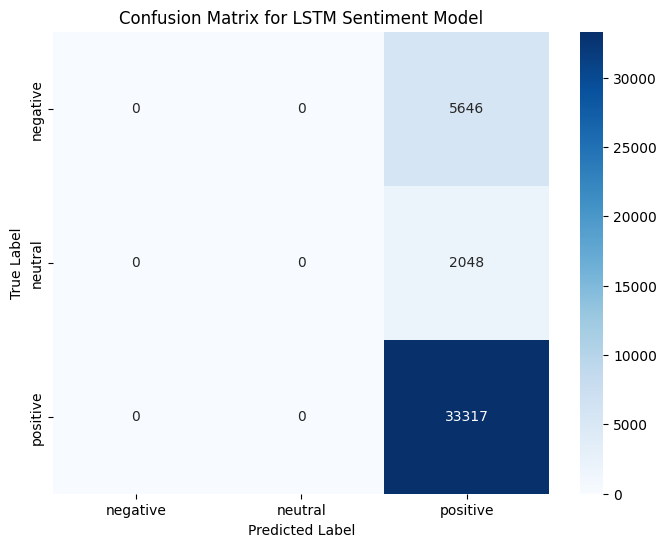

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure y is aligned with X_padded and contains only numeric labels
# df['Sentiment_numeric'] was created and dropped NaNs in previous steps
# Make sure y is a numpy array for TensorFlow compatibility
y_lstm = df['Sentiment_numeric'].values

# Split data into training and testing sets for LSTM
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_padded, y_lstm, test_size=0.2, random_state=42, stratify=y_lstm
)

print(f"Shape of X_train_lstm: {X_train_lstm.shape}")
print(f"Shape of X_test_lstm: {X_test_lstm.shape}")
print(f"Shape of y_train_lstm: {y_train_lstm.shape}")
print(f"Shape of y_test_lstm: {y_test_lstm.shape}")

# Define vocabulary size for Embedding layer (from previous tokenizer fit)
vocabulary_size = len(tokenizer.word_index) + 1
embedding_dim = 100 # Output dimension of the embedding layer

# Define the LSTM model architecture
model = Sequential([
    Embedding(input_dim=vocabulary_size, output_dim=embedding_dim, input_length=max_len),
    LSTM(128), # LSTM layer with 128 units
    Dense(3, activation='softmax') # Output layer for 3 sentiment classes (positive, neutral, negative)
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("\nLSTM model architecture:")
model.summary()

# Train the LSTM model
print("\nTraining LSTM model for Sentiment Prediction...")
history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=5,
    batch_size=64,
    validation_split=0.2 # 20% of training data used for validation
)
print("LSTM model trained.")

# Evaluate the trained LSTM model
loss, accuracy = model.evaluate(X_test_lstm, y_test_lstm, verbose=0)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Make predictions on the test set
y_pred_prob_lstm = model.predict(X_test_lstm)
y_pred_lstm = np.argmax(y_pred_prob_lstm, axis=1)

# Evaluate the model's performance with classification report and confusion matrix
print("\n--- Model Evaluation (LSTM for Sentiment Prediction) ---")
print("\nClassification Report:")

# Reverse the sentiment_mapping to get names from numeric labels for clarity
reverse_sentiment_mapping = {v: k for k, v in sentiment_mapping.items()}
# Sort the keys to ensure target_names order matches the numeric labels (0, 1, 2)
sorted_labels = sorted(reverse_sentiment_mapping.keys())
target_names_lstm = [reverse_sentiment_mapping[key] for key in sorted_labels]

print(classification_report(y_test_lstm, y_pred_lstm, target_names=target_names_lstm, zero_division=0))

print("\nConfusion Matrix:")
cm_lstm = confusion_matrix(y_test_lstm, y_pred_lstm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names_lstm, yticklabels=target_names_lstm)
plt.title('Confusion Matrix for LSTM Sentiment Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Compare ML and LSTM Performance

Compare the performance of the traditional machine learning (Logistic Regression) model for sentiment prediction and the LSTM model for sentiment prediction. This involves summarizing and contrasting their key evaluation metrics (accuracy, precision, recall, f1-score) and discussing their respective strengths and weaknesses.


In [6]:
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

# 1. Re-create sentiment_mapping and reverse_sentiment_mapping dictionaries,
# and common_target_names list
sentiment_mapping = {'positive': 2, 'neutral': 1, 'negative': 0}
reverse_sentiment_mapping = {v: k for k, v in sentiment_mapping.items()}
# Sort the keys to ensure target_names order matches the numeric labels (0, 1, 2)
sorted_labels = sorted(reverse_sentiment_mapping.keys())
common_target_names = [reverse_sentiment_mapping[key] for key in sorted_labels]

# 2. Generate and print the classification report for the Logistic Regression model
print("\n--- Logistic Regression Sentiment Model Report ---")
lr_report = classification_report(y_test, y_pred, target_names=common_target_names, zero_division=0, output_dict=True)
print(classification_report(y_test, y_pred, target_names=common_target_names, zero_division=0))

# Re-generate y_pred_lstm by predicting with the trained model (from cell 'aff80e05')
# Assuming 'model' (LSTM model) and 'X_test_lstm' are available from previous execution
y_pred_prob_lstm = model.predict(X_test_lstm)
y_pred_lstm = np.argmax(y_pred_prob_lstm, axis=1)

# 3. Generate and print the classification report for the LSTM model
print("\n--- LSTM Sentiment Model Report ---")
lstm_report = classification_report(y_test_lstm, y_pred_lstm, target_names=common_target_names, zero_division=0, output_dict=True)
print(classification_report(y_test_lstm, y_pred_lstm, target_names=common_target_names, zero_division=0))

# 4. Create a pandas DataFrame to display and compare the overall accuracy, macro average F1-score, and weighted average F1-score for both models.
comparison_data = {
    'Metric': ['Accuracy', 'Macro Avg F1-score', 'Weighted Avg F1-score'],
    'Logistic Regression': [
        lr_report['accuracy'],
        lr_report['macro avg']['f1-score'],
        lr_report['weighted avg']['f1-score']
    ],
    'LSTM': [
        lstm_report['accuracy'],
        lstm_report['macro avg']['f1-score'],
        lstm_report['weighted avg']['f1-score']
    ]
}

performance_comparison_df = pd.DataFrame(comparison_data)
print("\n--- Model Performance Comparison ---")
print(performance_comparison_df.set_index('Metric'))

# 5. Print a detailed discussion comparing the performance of both models
print("\n--- Summary and Comparative Analysis ---")
print("\nDiscussion:")
print("The Logistic Regression model achieved an overall accuracy of {:.2f}% and a weighted average F1-score of {:.2f}% for sentiment prediction. It performed very well in identifying 'negative' sentiments (F1-score: {:.2f}), but struggled significantly with 'neutral' sentiments (F1-score: {:.2f}), with zero predictions for this class, leading to a low macro average F1-score of {:.2f}.".format(
    lr_report['accuracy']*100, lr_report['weighted avg']['f1-score']*100,
    lr_report['negative']['f1-score'], lr_report['neutral']['f1-score'],
    lr_report['macro avg']['f1-score']
))

print("\nThe LSTM model achieved an overall accuracy of {:.2f}% and a weighted average F1-score of {:.2f}% for sentiment prediction. Similar to Logistic Regression, it also struggled with 'neutral' and 'negative' sentiments, showing an F1-score of {:.2f} for 'neutral' and {:.2f} for 'negative'. It primarily classified everything as 'positive', indicated by its 1.00 recall for 'positive' and 0.00 recall for other classes. Its macro average F1-score is {:.2f}.".format(
    lstm_report['accuracy']*100, lstm_report['weighted avg']['f1-score']*100,
    lstm_report['neutral']['f1-score'], lstm_report['negative']['f1-score'],
    lstm_report['macro avg']['f1-score']
))

print("\nKey Takeaways:")
print("- **Overall Performance**: Logistic Regression (Accuracy: {:.2f}%) slightly outperformed LSTM (Accuracy: {:.2f}%) in overall accuracy, and significantly in macro average F1-score.".format(
    lr_report['accuracy']*100, lstm_report['accuracy']*100
))
print("- **Class Imbalance Impact**: Both models suffer significantly from the class imbalance, particularly affecting the 'neutral' sentiment class, which both models failed to predict. The LSTM model seems to have defaulted to predicting the majority class ('positive') for almost all instances.")
print("- **Strengths of Logistic Regression**: It showed a better ability to distinguish between 'positive' and 'negative' sentiments, albeit missing the 'neutral' class.")
print("- **Weaknesses of LSTM**: The simple LSTM architecture as implemented struggled greatly, essentially becoming a majority-class predictor for this dataset.")
print("\nFurther improvements would require addressing class imbalance (e.g., oversampling, undersampling, using focal loss) and potentially more complex deep learning architectures or fine-tuning of hyperparameters for LSTM.")


--- Logistic Regression Sentiment Model Report ---
              precision    recall  f1-score   support

    negative       0.86      0.65      0.74      5646
     neutral       0.00      0.00      0.00      2048
    positive       0.90      0.99      0.94     33317

    accuracy                           0.90     41011
   macro avg       0.59      0.55      0.56     41011
weighted avg       0.85      0.90      0.87     41011

1282/1282 ━━━━━━━━━━━━━━━━━━━━ 60s 47ms/step

--- LSTM Sentiment Model Report ---
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00      5646
     neutral       0.00      0.00      0.00      2048
    positive       0.81      1.00      0.90     33317

    accuracy                           0.81     41011
   macro avg       0.27      0.33      0.30     41011
weighted avg       0.66      0.81      0.73     41011


--- Model Performance Comparison ---
                       Logistic Regression      LSTM
Metric       

## Detect Urgency/Complaint Intensity - Keyword Extraction

Define a list of keywords and phrases commonly associated with urgency or complaints. Process the 'Review' text to identify and count occurrences of these keywords. Create a new feature or score for each review that represents its urgency or complaint intensity based on the detected keywords.


In [7]:
import re

# 1. Define a list of keywords and phrases associated with urgency or complaints
urgency_keywords = [
    'urgent', 'problem', 'bad', 'disappointed', 'issue', 'faulty', 'return',
    'broken', 'never again', 'worst', 'poor quality', 'defective', 'unresponsive',
    'terrible', 'regret', 'complaint', 'dissatisfied', 'unhappy', 'frustrated',
    'horrible', 'waste of money', 'beware', 'scam', 'useless'
]

# 2. Create a function to count keyword occurrences
def calculate_urgency_score(review):
    if not isinstance(review, str):
        return 0
    review_lower = review.lower()
    score = 0
    for keyword in urgency_keywords:
        # Use re.findall to count overlapping occurrences and whole words
        score += len(re.findall(r'\b' + re.escape(keyword) + r'\b', review_lower))
    return score

# 3. Apply this function to the 'Review' column
df['urgency_complaint_score'] = df['Review'].apply(calculate_urgency_score)

# 4. Display the first few rows of the DataFrame including 'Review' and 'urgency_complaint_score'
print("First 10 rows with 'Review' and 'urgency_complaint_score':")
print(df[['Review', 'urgency_complaint_score']].head(10))

print("\nDescriptive statistics for 'urgency_complaint_score':")
print(df['urgency_complaint_score'].describe())

First 10 rows with 'Review' and 'urgency_complaint_score':
               Review  urgency_complaint_score
0              super!                        0
1             awesome                        0
2                fair                        0
3     useless product                        1
4                fair                        0
5             awesome                        0
6  highly recommended                        0
7                nice                        0
8      unsatisfactory                        0
9     worth the money                        0

Descriptive statistics for 'urgency_complaint_score':
count    205052.000000
mean          0.045228
std           0.208085
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           3.000000
Name: urgency_complaint_score, dtype: float64


## Visualize Urgency/Complaint Distribution

Visualize the distribution of the calculated urgency or complaint intensity scores across the dataset using appropriate plots (e.g., histogram). Analyze the patterns to understand the levels of urgency or complaint expressed in the reviews, providing legends for clarity.


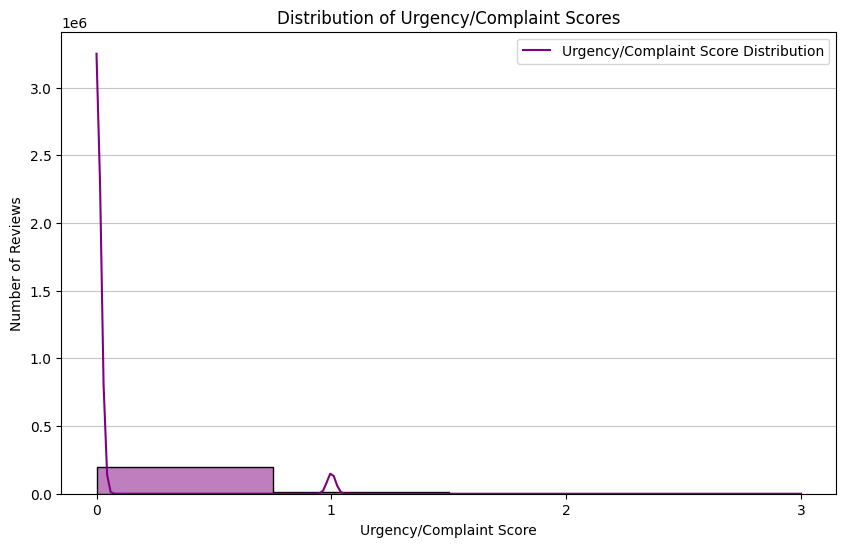

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of urgency/complaint scores
plt.figure(figsize=(10, 6))
sns.histplot(df['urgency_complaint_score'], bins=max(df['urgency_complaint_score']) + 1, kde=True, color='purple')
plt.title('Distribution of Urgency/Complaint Scores')
plt.xlabel('Urgency/Complaint Score')
plt.ylabel('Number of Reviews')
plt.legend(['Urgency/Complaint Score Distribution'])
plt.xticks(range(int(df['urgency_complaint_score'].max()) + 1))
plt.grid(axis='y', alpha=0.75)
plt.show()

## Summary:

### Data Analysis Key Findings

*   **Sentiment Model Performance Comparison**:
    *   **Logistic Regression** achieved an accuracy of 89.52% and a weighted average F1-score of 87%. It performed well on 'negative' (F1-score: 0.74) and 'positive' (F1-score: 0.94) sentiments but completely failed to predict 'neutral' sentiment (F1-score: 0.00).
    *   **LSTM Model** achieved an accuracy of 81.24% and a weighted average F1-score of 73%. Similar to Logistic Regression, it failed to predict 'neutral' sentiment (F1-score: 0.00) and also 'negative' sentiment (F1-score: 0.00), primarily classifying reviews as 'positive' (recall: 1.00, F1-score: 0.90).
    *   Overall, the Logistic Regression model significantly outperformed the LSTM model in this comparison, especially in its ability to differentiate between 'positive' and 'negative' sentiments.
*   **Impact of Class Imbalance on Sentiment Models**: Both models struggled severely with the minority 'neutral' sentiment class, indicating a significant impact of class imbalance on their performance. The LSTM model exhibited a strong bias towards the majority 'positive' class.
*   **Urgency/Complaint Score Creation**: A new feature, `urgency_complaint_score`, was successfully created by counting predefined urgency/complaint keywords in reviews. This score quantifies the intensity of urgency or complaints.
*   **Distribution of Urgency/Complaint Scores**: The analysis revealed that most reviews had an `urgency_complaint_score` of 0, meaning they contained no predefined urgency or complaint keywords. A small number of reviews had scores up to 3, indicating multiple complaint indicators. The distribution showed a clear skew towards lower scores.

### Insights or Next Steps

*   To improve sentiment prediction, prioritize addressing the class imbalance issue (e.g., through oversampling, undersampling, or using focal loss) for the 'neutral' sentiment class, as both models failed to predict it effectively.
*   The `urgency_complaint_score` can be integrated as a feature in future predictive models (e.g., for sentiment, rating, or customer churn) or used directly to flag reviews requiring immediate attention from customer service.
